In [1]:
import numpy as np
import pylab as plt
from scipy import stats
from numpy import random
from scipy.stats import lognorm
from scipy.stats import truncnorm
from scipy.stats import norm

# Here we are doing the DM convolutions to constrain $DM_{M31}$ and $DM_{M31,halo}$. At first we are doing

# $\mathcal{P}(DM_{M31})= \mathcal{P}(DM_{obs})* \mathcal{P}(-DM_{IGM})*\mathcal{P}(-DM_{host})*\mathcal{P}(-DM_{MW,disk})*\mathcal{P}(DM_{-MW,halo})$

In [2]:
def reflect_pdf(x, pdf):
    # reflect distribution: p(-x)
    return np.interp(x, -x[::-1], pdf[::-1], left=0, right=0)

def split_normal_pdf(x, mu, sigma_left, sigma_right):
    return np.where(
        x < mu,
        norm.pdf(x, loc=mu, scale=sigma_left),
        norm.pdf(x, loc=mu, scale=sigma_right)
    )
def normalize(pdf, x):
    area = np.trapz(pdf, x)
    if area <= 0 or not np.isfinite(area):
        raise ValueError("PDF area is non-positive or non-finite; check inputs.")
    return pdf /area

In [3]:
XMAX = 1000.0
N = 2000                
x = np.linspace(-XMAX, XMAX, N)

# Repeater LOS

In [4]:
#OBSERVED DM: split_normal distribution.
rdmobs_x = np.linspace(-1000, 1000, 2000) 
rp_dmobs = split_normal_pdf(x, mu=772, sigma_left=2, sigma_right=3)   
rp_dmobs[x < 0] = 0.0# direct on (x); setting negative values to zero probability 
rp_dmobs = normalize(rp_dmobs, x) # renormalizing so that the probability sums to 1.

In [5]:
# MW disk: truncated Gaussian (truncate at lower_bound)
mean, std_dev = 68, 20
lower_bound, upper_bound = 53, np.inf # lower bound based on nearby pulsar
a = (lower_bound - mean) / std_dev
b = (upper_bound - mean) / std_dev
trunc_gauss = truncnorm(a, b, loc=mean, scale=std_dev)
rp_dmmwdisk = trunc_gauss.pdf(x) # below 53 gets ~0 automatically
rp_dmmwdisk = normalize(rp_dmmwdisk, x)

# MW halo: Normal(38, 19) based on Ravi et al 2025
rp_dmmwhalo = stats.norm.pdf(x, loc=38, scale=19)
rp_dmmwhalo[x < 0] = 0.0  #setting negative values to zero probability
rp_dmmwhalo = normalize(rp_dmmwhalo, x)

In [6]:
# From Macquart et al 2020
rp_dmigm=np.loadtxt('dmigm_rep_withhalos.txt')
rdmigm_x=np.linspace(-1000,1000,2000)
rp_dmigm[x<0] = 0.0  #setting negative values to zero probability
rp_dmigm=normalize(rp_dmigm, x)

In [7]:
# Host ISM: lognormal with (sigma=0.56, mu=4.9) in natural-log params. From Connor et al 2025
sigma_ln, mu_ln = 0.56, 4.9
rp_dmhost = lognorm.pdf(x, s=sigma_ln, scale=np.exp(mu_ln)) 
rp_dmhost[x<0]=0 #  setting negative values to zero probability
rp_dmhost = normalize(rp_dmhost, x)

In [8]:
#Negating the observed and the M31 DM
rp_dmobs_neg = reflect_pdf(x, rp_dmobs)  

In [9]:
rp_dmmw=np.convolve(rp_dmmwdisk,rp_dmmwhalo,'same')
rp_mwigm=np.convolve(rp_dmmw,rp_dmigm,'same')
rp_mwigmhost=np.convolve(rp_mwigm,rp_dmhost,'same')
rp_mwigmhostobs=np.convolve(rp_mwigmhost,rp_dmobs_neg,'same')

In [10]:
dmm31=reflect_pdf(x, rp_mwigmhostobs) 
dmm31[x<0]=0 # setting negative DM to zero probability 
dmm31=normalize(dmm31, x)

In [11]:
A = x
P = dmm31
# Compute the CDF
cdf = np.cumsum(P)
# Find the 50th percentile (median)
rmedian =A[np.where(cdf >= 0.5)[0][0]]
print('median of  DMm31=',rmedian)
rpercentile_10 = A[np.where(cdf >= 0.05)[0][0]]
# Find the 90th percentile
rpercentile_90 = A[np.where(cdf >= 0.95)[0][0]]
print("The 90% credible interval is: [{}, {}]".format(rpercentile_10, rpercentile_90))


median of  DMm31= 238.61930965482748
The 90% credible interval is: [51.52576288144087, 365.6828414207105]


# Non Repeater LOS

In [12]:
XMAX = 500
N = 1000              
x = np.linspace(-XMAX, XMAX, N)
dmmw_x =x

In [13]:
#OBSERVED
dmobs_x = np.linspace(-500, 500, 1000)  
p_dmobs = split_normal_pdf(x, mu=456,sigma_left=0.6,sigma_right=0.5)   
p_dmobs[x < 0] = 0.0
p_dmobs = normalize(p_dmobs, x)

In [14]:
# MW disk: truncated Gaussian (truncate at lower_bound)
mean, std_dev = 70, 21
lower_bound, upper_bound = 53, np.inf
a = (lower_bound - mean) / std_dev
b = (upper_bound - mean) / std_dev
trunc_gauss = truncnorm(a, b, loc=mean, scale=std_dev)
p_dmmwdisk = trunc_gauss.pdf(x)        # below 53 gets ~0 automatically
p_dmmwdisk = normalize(p_dmmwdisk, x)

# MW halo: Normal(38, 19)
p_dmmwhalo = stats.norm.pdf(x, loc=38, scale=11)
p_dmmwhalo[x < 0] = 0.0
p_dmmwhalo = normalize(p_dmmwhalo, x)

In [15]:
# DM IGM
p_dmigm=np.loadtxt('dmigm_nonrep.txt')
p_dmigm[x < 0] = 0.0
p_dmigm=normalize(p_dmigm, x)
dmigm_x=np.linspace(-500,500,1000)

In [16]:
# Host ISM: lognormal with (sigma=0.56, mu=4.9) in natural-log params
sigma_ln, mu_ln = 0.56, 4.9
p_dmhost = lognorm.pdf(x, s=sigma_ln, scale=np.exp(mu_ln))
p_dmhost[x < 0] = 0.0# returns 0 for x<=0
p_dmhost = normalize(p_dmhost, x)

In [17]:
p_dmobs_neg = reflect_pdf(x, p_dmobs)  

In [18]:
p_dmmw=np.convolve(p_dmmwdisk,p_dmmwhalo,'same')
p_mwigm=np.convolve(p_dmmw,p_dmigm,'same')
p_mwigmhost=np.convolve(p_mwigm,p_dmhost,'same')
p_mwigmhostobs=np.convolve(p_mwigmhost,p_dmobs_neg,'same')

In [19]:
dmm31_nonrep=reflect_pdf(x, p_mwigmhostobs) 
dmm31_nonrep[x<0]=0
dmm31_nonrep=normalize(dmm31_nonrep,x)

In [20]:
A = x
P = dmm31_nonrep
cdf = np.cumsum(P)
# Find the 50th percentile (median)
median =A[np.where(cdf >= 0.5)[0][0]]
print('median of  DMm31=',median)
low_68  = A[np.where(cdf >= 0.16)[0][0]]
high_68 = A[np.where(cdf >= 0.84)[0][0]]
print("68% CI:", low_68, high_68)
percentile_10 = A[np.where(cdf >= 0.05)[0][0]]
# Find the 90th percentile
percentile_90 = A[np.where(cdf >= 0.95)[0][0]]
print("The 90% credible interval is: [{}, {}]".format(percentile_10, percentile_90))

median of  DMm31= 145.6456456456457
68% CI: 69.56956956956958 206.70670670670677
The 90% credible interval is: [27.52752752752758, 236.73673673673682]


In [21]:
plt.rcParams['figure.figsize'  ] = (12,5)
plt.rcParams['font.size'       ] = 12
plt.rcParams['legend.fontsize' ] = 12
plt.rcParams['legend.frameon'  ] = False
plt.rcParams['font.family'     ] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction' ] = 'in'
plt.rcParams['ytick.direction' ] = 'in'
plt.rcParams['xtick.top'       ] = True
plt.rcParams['ytick.right'     ] = True
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.major.width'] = 0.75
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.75
plt.rcParams['ytick.minor.width'] = 0.5

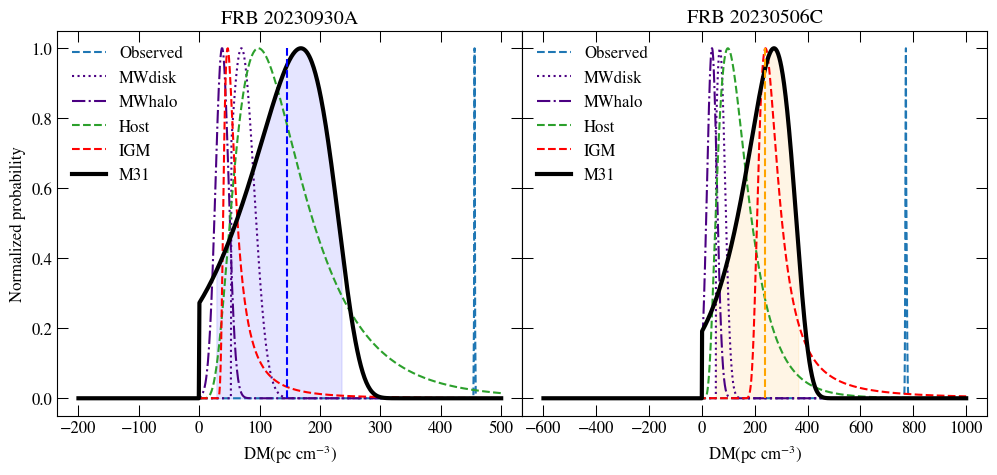

In [22]:
fig, ((ax1,ax2)) = plt.subplots(1, 2,sharey=True,gridspec_kw={'wspace': 0.0})

ax1.plot(dmobs_x[300:],(p_dmobs/np.max(p_dmobs))[300:],label='Observed',linestyle='dashed')
ax1.plot(dmmw_x[300:],(p_dmmwdisk/np.max(p_dmmwdisk))[300:],label='MWdisk',linestyle='dotted',color='indigo')
ax1.plot(dmmw_x[300:],(p_dmmwhalo/np.max(p_dmmwhalo))[300:],label='MWhalo',linestyle='dashdot',color='indigo')
ax1.plot(dmmw_x[300:],(p_dmhost/np.max(p_dmhost))[300:],label='Host',linestyle='dashed',color='tab:green')
#plt.plot(dmmw_x[300:],(p_dmhosthalo/np.max(p_dmhosthalo))[300:],label='Host halo',linestyle='dashdot',color='tab:green')
ax1.plot(dmmw_x[300:],(p_dmigm/np.max(p_dmigm))[300:],label='IGM',linestyle='dashed',color='red')
ax1.plot(dmmw_x[300:],(dmm31_nonrep/np.max(dmm31_nonrep))[300:],label='M31',color='black',linewidth='3')
ax1.fill_between(dmmw_x,(dmm31_nonrep/np.max(dmm31_nonrep)),0,
                 where=(dmmw_x > percentile_10) & (dmmw_x < percentile_90),color='blue',alpha=0.1)
ax1.vlines(median,0,1,linestyle='dashed',color='b')
ax1.set_xlabel(r'$\rm DM (pc~cm^{-3})$')
ax1.set_ylabel('Normalized probability')
ax1.legend(loc='upper left')
ax1.set_title('FRB 20230930A')

ax2.plot(rdmobs_x[400:],(rp_dmobs/np.max(rp_dmobs))[400:],label='Observed',linestyle='dashed')
ax2.plot(rdmobs_x[400:],(rp_dmmwdisk/np.max(rp_dmmwdisk))[400:],label='MWdisk',linestyle='dotted',color='indigo')
ax2.plot(rdmobs_x[400:],(rp_dmmwhalo/np.max(rp_dmmwhalo))[400:],label='MWhalo',linestyle='dashdot',color='indigo')
ax2.plot(rdmobs_x[400:],(rp_dmhost/np.max(rp_dmhost))[400:],label='Host',linestyle='dashed',color='tab:green')
#plt.plot(dmmw_x[300:],(p_dmhosthalo/np.max(p_dmhosthalo))[300:],label='Host halo',linestyle='dashdot',color='tab:green')
ax2.plot(rdmobs_x[400:],(rp_dmigm/np.max(rp_dmigm))[400:],label='IGM',linestyle='dashed',color='red')
ax2.plot(rdmobs_x[400:],(dmm31/np.max(dmm31))[400:],label='M31',color='black',linewidth='3')
#cond = ( > 10) & (y < 80)
ax2.fill_between(rdmobs_x,(dmm31/np.max(dmm31)),0,
                 where=(rdmobs_x > rpercentile_10) & (rdmobs_x <rpercentile_90),color='orange',alpha=0.1)
ax2.vlines(rmedian,0,1,linestyle='dashed',color='orange')
ax2.set_xlabel(r'$\rm DM (pc~cm^{-3})$')
#ax2.set_ylabel('Normalized probability')
ax2.legend(loc='upper left')
ax2.set_title('FRB 20230506C')
plt.savefig('DM_pdfs_totalM31.pdf',bbox_inches='tight',dpi=300)

# We have now calculated the total $DM_{M31}$. However, the non-repeater FRB passes right through its disk and will have a large contribution from the M31's disk. Therefore, we should model the disk contribution and remove that. The disk modeling is done in a separate notebook. 

# $\mathcal{P}DM_{M31,halo} = \mathcal{P}DM_{M31}*\mathcal{P}DM_{M31,disk}$

# This calculation is only done for the non-repeater LOS.

In [23]:
# mean = 128 for impact parameter ~3 kpc. From Disk modeling notebook.
dmdisk_x=np.linspace(-500,500,1000)
p_dmdisk=stats.norm.pdf(dmobs_x,loc=128,scale=64) #64
p_dmdisk[x<0]=0
p_dmdisk_neg=reflect_pdf(dmdisk_x, p_dmdisk)
p_dmdisk_neg=normalize(p_dmdisk_neg,dmdisk_x)

In [24]:
p_m31halo=np.convolve(dmm31_nonrep,p_dmdisk_neg,'same')
p_m31halo[x<0]=0
p_m31halo=normalize(p_m31halo,dmdisk_x)

In [25]:
A = dmdisk_x[:] 
cdf_a = np.cumsum(p_m31halo)
median_a =A[np.where(cdf_a >= 0.5)[0][0]]
percentile_10_a = A[np.where(cdf_a >= 0.05)[0][0]]
percentile_90_a = A[np.where(cdf_a >= 0.95)[0][0]]
print('median of DM M31 halo model (a)=',median_a)
print("The 90% uncertainty interval for halo DM model (a) is: [{}, {}]".format(percentile_10_a, percentile_90_a))
ci_68 = np.percentile(p_m31halo, [16, 84])

median of DM M31 halo model (a)= 64.56456456456465
The 90% uncertainty interval for halo DM model (a) is: [6.5065065065065255, 168.66866866866872]


In [26]:
plt.rcParams['figure.figsize'  ] = (6,5)
plt.rcParams['font.size'       ] = 12
plt.rcParams['legend.fontsize' ] = 12
plt.rcParams['legend.frameon'  ] = False
plt.rcParams['font.family'     ] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction' ] = 'in'
plt.rcParams['ytick.direction' ] = 'in'
plt.rcParams['xtick.top'       ] = True
plt.rcParams['ytick.right'     ] = True
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.major.width'] = 0.75
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.75
plt.rcParams['ytick.minor.width'] = 0.5

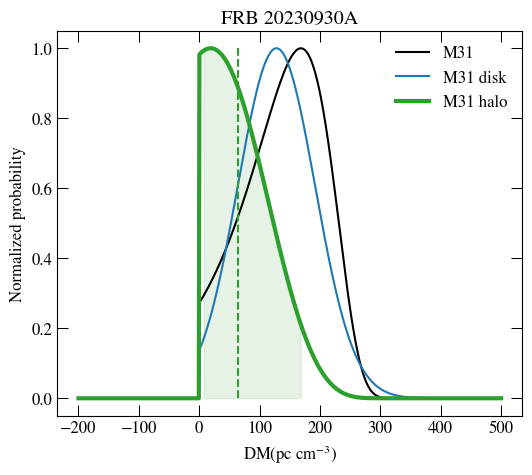

In [27]:
fig, ax = plt.subplots(1, 1)
ax.plot(dmmw_x[300:],(dmm31_nonrep/np.max(dmm31_nonrep))[300:],label='M31',color='black')
ax.plot(dmdisk_x[300:],(p_dmdisk/np.max(p_dmdisk))[300:],label='M31 disk',color='tab:blue')
ax.plot(dmdisk_x[300:],(p_m31halo/np.max(p_m31halo))[300:],label='M31 halo', color='tab:green',linewidth='3')
ax.fill_between(dmdisk_x,(p_m31halo/np.max(p_m31halo)),0,
                 where=(dmdisk_x > percentile_10_a) & (dmdisk_x <percentile_90_a),color='green',alpha=0.1)
ax.vlines(median_a,0,1,linestyle='dashed',color='tab:green')
ax.legend()
ax.set_xlabel(r'$\rm DM (pc~cm^{-3})$')
ax.set_ylabel('Normalized probability')
ax.set_title('FRB 20230930A')
plt.savefig('DM_M31halo.pdf',bbox_inches='tight',dpi=300)